<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
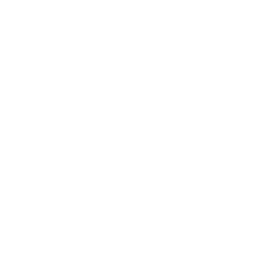
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Steel Mill Rolling Process Monitoring</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Multivariate SPC for hot strip mill thickness and surface quality control &nbsp;|&nbsp; March 2026</p>
</div>
</div>
</div>

## Zusammenfassung

Ein Warmbandwalzwerk walzt Stahlbrammen zu dünnem Coil. Acht korrelierte
Prozesssignale (Dicken, Walzkraft, Walzspalt, Motorstrom,
Austrittstemperatur) bewegen sich gemeinsam, wenn die Anlage gesund läuft,
sodass die Überwachung nur eines Diagramms nach dem anderen die
gemeinsamen Verschiebungen übersieht, auf die es ankommt. Dieses Beispiel
baut mit **PROC MVPMODEL** eine multivariate Baseline auf und lässt dann
100 Produktions-Coils durch **PROC MVPMONITOR** laufen, das jedes Coil
mit einer einzigen Hotelling-*T*&sup2;-Statistik bewertet und sie mit
einer Regelgrenze vergleicht.

Gegenüber einer Regelgrenze von *T*&sup2; = **17,13** (&alpha; = 0,05)
signalisieren **4 von 100 Coils** einen außer Kontrolle geratenen Zustand
— die Coils **91, 92, 94 und 95**, genau das Fenster, in dem ein
Stützwalzen-Chatter-Ausbruch eingebracht wurde. Der Spitzenwert von
*T*&sup2; erreicht **21,91** bei Coil 95, etwa das **1,3-Fache** der
Grenze. Die allmähliche Rampe des Walzenverschleißes über die späteren
Coils hebt die Baseline von *T*&sup2; an, bleibt aber bis zum
Chatter-Ereignis unter der Grenze, so dass das Diagramm langsame Drift
sauber vom akuten Fehler trennt, der sofortige Aufmerksamkeit erfordert.


## Datenquellen

- **mill_baseline** — 50 Coils, gewalzt während einer bekannt guten
  Phase der Kampagne; dient zur Anpassung des multivariaten
  (PCA-)Referenzmodells.
- **mill_stream** — 100 Coils aus der laufenden Anlage. Coils 1–55
  laufen im Regelzustand; der Walzenverschleiß entwickelt sich
  allmählich über die Coils 56–100; ein Stützwalzen-Chatter-Ausbruch
  trifft die Coils 91–95.
- **Prozessvariablen** (6): `entry_thickness`, `exit_thickness`,
  `rolling_force`, `roll_gap`, `motor_current`, `exit_temp`.

> Die Umgebung läuft unlizenziert, daher sind die Datensätze auf 100
> Beobachtungen begrenzt. Das Szenario ist auf diese Grenze zugeschnitten:
> die Störung wird spät in einem 100-Coil-Strom platziert statt bei
> Coil 2.800 von 5.000.


---

### Schritt 1 — Aufbau des multivariaten Referenzmodells

`PROC MVPMODEL` führt eine Hauptkomponentenanalyse der sechs
Prozessvariablen auf der Baseline im Regelzustand durch und schreibt die
Ladungen, Eigenwerte sowie Zentrierung/Skalierung nach `mill_model`. Drei
Komponenten werden beibehalten. Dieses Modell definiert, wie "normal"
als eine einzige multivariate Region aussieht, statt als sechs
unabhängige Wertebereiche.


In [1]:
DATEN mill_baseline;
  AUFRUFEN streaminit(66);
  AUSFÜHRUNG coil_id = 1 BIS 50;
    entry_thickness = 25.00 + rand('normal', 0, 0.30);
    exit_thickness  =  3.00 + rand('normal', 0, 0.030);
    rolling_force   = 18000 + rand('normal', 0, 150);
    roll_gap        =  2.85 + rand('normal', 0, 0.015);
    motor_current   =   850 + rand('normal', 0, 8);
    exit_temp       =   880 + rand('normal', 0, 4.0);
    AUSGABE;
  ENDE;
AUSFÜHREN;

PROZEDUR mvpmodel DATEN=mill_baseline outmodel=mill_model;
  VAR entry_thickness exit_thickness rolling_force
      roll_gap motor_current exit_temp;
  ncomp=3;
AUSFÜHREN;



                    The MVPMODEL Procedure

  Data Set:          mill_baseline
  Number of Variables: 6
  Missing Value Handling: Exclude
  Number of Observations Read: 50
  Number of Observations Used: 50
  Number of Principal Components: 3

  Correlation Matrix
         entry_thicknessexit_thicknessrolling_force  roll_gapmotor_current exit_temp
  entry_thickness    1.0000   -0.0416   -0.1641   -0.1661    0.1555    0.0649
  exit_thickness   -0.0416    1.0000    0.0406    0.0029    0.0946   -0.1421
  rolling_force   -0.1641    0.0406    1.0000   -0.1351    0.2077   -0.0051
  roll_gap   -0.1661    0.0029   -0.1351    1.0000   -0.0510   -0.0876
  motor_current    0.1555    0.0946    0.2077   -0.0510    1.0000    0.1587
  exit_temp    0.0649   -0.1421   -0.0051   -0.0876    0.1587    1.0000

  Eigenvalues of the Correlation Matrix
       Eigenvalue   Difference   Proportion  Cumulative
    1 1.37232115  0.14267284    0.2287    0.2287
    2 1.22964831  0.16747324    0.2049    0.4337
    3


NOTE: DATA mill_baseline


NOTE: Wrote mill_baseline (50 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC MVPMODEL
NOTE: PROC MVPMODEL statement used.


---

### Schritt 2 — Produktions-Coils streamen und bewerten

`PROC MVPMONITOR` projiziert jeden der 100 Produktions-Coils auf das
gespeicherte Modell und berechnet sein Hotelling-*T*&sup2;. Die Prozedur
leitet die Regelgrenze aus den Modelldimensionen und dem Standardwert
&alpha; = 0,05 ab und markiert dann jedes Coil, dessen *T*&sup2; sie
überschreitet. Die Ergebnisse, einschließlich der Spalten `_TSQUARED`,
`_LIMIT` und `_SIGNAL`, werden nach `mill_scores`, indiziert über
`coil_id`, geschrieben.


In [2]:
DATEN mill_stream;
  AUFRUFEN streaminit(42);
  AUSFÜHRUNG coil_id = 1 BIS 100;
    /* Walzenverschleiß rampt von 0 auf 1 ueber die Coils 56-100 */
    wear    = MAX(0, coil_id - 55) / 45;
    /* Stuetzwalzen-Chatter-Ausbruch bei den Coils 91-95 */
    chatter = (coil_id >= 91 UND coil_id <= 95);
    entry_thickness = 25.00 + rand('normal', 0, 0.30);
    exit_thickness  =  3.00 + wear*0.10 + chatter*0.35
                            + rand('normal', 0, 0.030);
    rolling_force   = 18000 + wear*600  + chatter*1600
                            + rand('normal', 0, 150);
    roll_gap        =  2.85 + wear*0.055
                            + rand('normal', 0, 0.015);
    motor_current   =   850 + wear*38   + chatter*95
                            + rand('normal', 0, 8);
    exit_temp       =   880 + rand('normal', 0, 4.0);
    ENTFERNEN wear chatter;
    AUSGABE;
  ENDE;
AUSFÜHREN;

PROZEDUR mvpmonitor DATEN=mill_stream model=mill_model
                out=mill_scores;
  VAR entry_thickness exit_thickness rolling_force
      roll_gap motor_current exit_temp;
  id coil_id;
AUSFÜHREN;



                    The MVPMONITOR Procedure

  Variables:       6
  Observations:    100
  T2 Limit:        17.1334
  Signals:         4





NOTE: DATA mill_stream


NOTE: Wrote mill_stream (100 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC MVPMONITOR
NOTE: PROC MVPMONITOR statement used.


Die Prozedurzusammenfassung meldet die Regelgrenze und die Anzahl der
Signale. Der unten gedruckte Ausschnitt rund um die Störung zeigt, dass
die Baseline-Coils deutlich unter der Grenze liegen, während das
Chatter-Fenster vier Coils darüber treibt.


In [3]:
/* Auffaellige (nicht regelkonforme) Coils markieren und den Alarm-T2 fuer die Grafik erfassen */
DATEN mill_scores;
  FESTLEGEN mill_scores;
  WENN _SIGNAL = 1 DANN t2_alarm = _TSQUARED;
  SONST t2_alarm = .;
AUSFÜHREN;

PROC PRINT DATEN=mill_scores(firstobs=88 obs=96) noobs;
  VAR coil_id _TSQUARED _LIMIT _SIGNAL;
  BEZEICHNUNG coil_id='Coil-ID' _TSQUARED='T2-Wert' _LIMIT='Regelgrenze' _SIGNAL='Signal';
  TITEL 'T2-Werte im Chatter-Fenster (Coils 88-96)';
AUSFÜHREN;


                                       T2-Werte im Chatter-Fenster (Coils 88-96)                                        

Coil-ID    T2-Wert  Regelgrenze  Signal
     88   9.983151    17.133408       0
     89   2.915646    17.133408       0
     90    7.80613    17.133408       0
     91  18.813814    17.133408       1
     92  18.249361    17.133408       1
     93  16.638221    17.133408       0
     94  17.981792    17.133408       1
     95  21.912329    17.133408       1
     96   5.118574    17.133408       0

... 4 more observations (showing 9 of 13)




NOTE: DATA mill_scores


NOTE: Read 100 rows from mill_scores.
NOTE: Wrote mill_scores (100 rows, 25 columns).
NOTE: DATA elapsed:
  wall  0.03 seconds
  cpu   0.03 seconds
NOTE: PROC PRINT data=mill_scores

NOTE: PROC PRINT completed: 9 observations printed, 4 variables


---

### Schritt 3 — Multivariate Regelkarte

Das Diagramm überlagert das *T*&sup2; je Coil mit seiner Regelgrenze.
Außer Kontrolle geratene Coils sind rot hervorgehoben; die gestrichelte
vertikale Markierung kennzeichnet den Beginn des Chatter-Ausbruchs. Der
langsame Anstieg nach rechts ist der Walzenverschleiß, der die Baseline
anhebt; die vier roten Punkte sind der akute Chatter-Fehler.


                                       T2-Werte im Chatter-Fenster (Coils 88-96)                                        




NOTE: PROC SGPLOT data=mill_scores

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


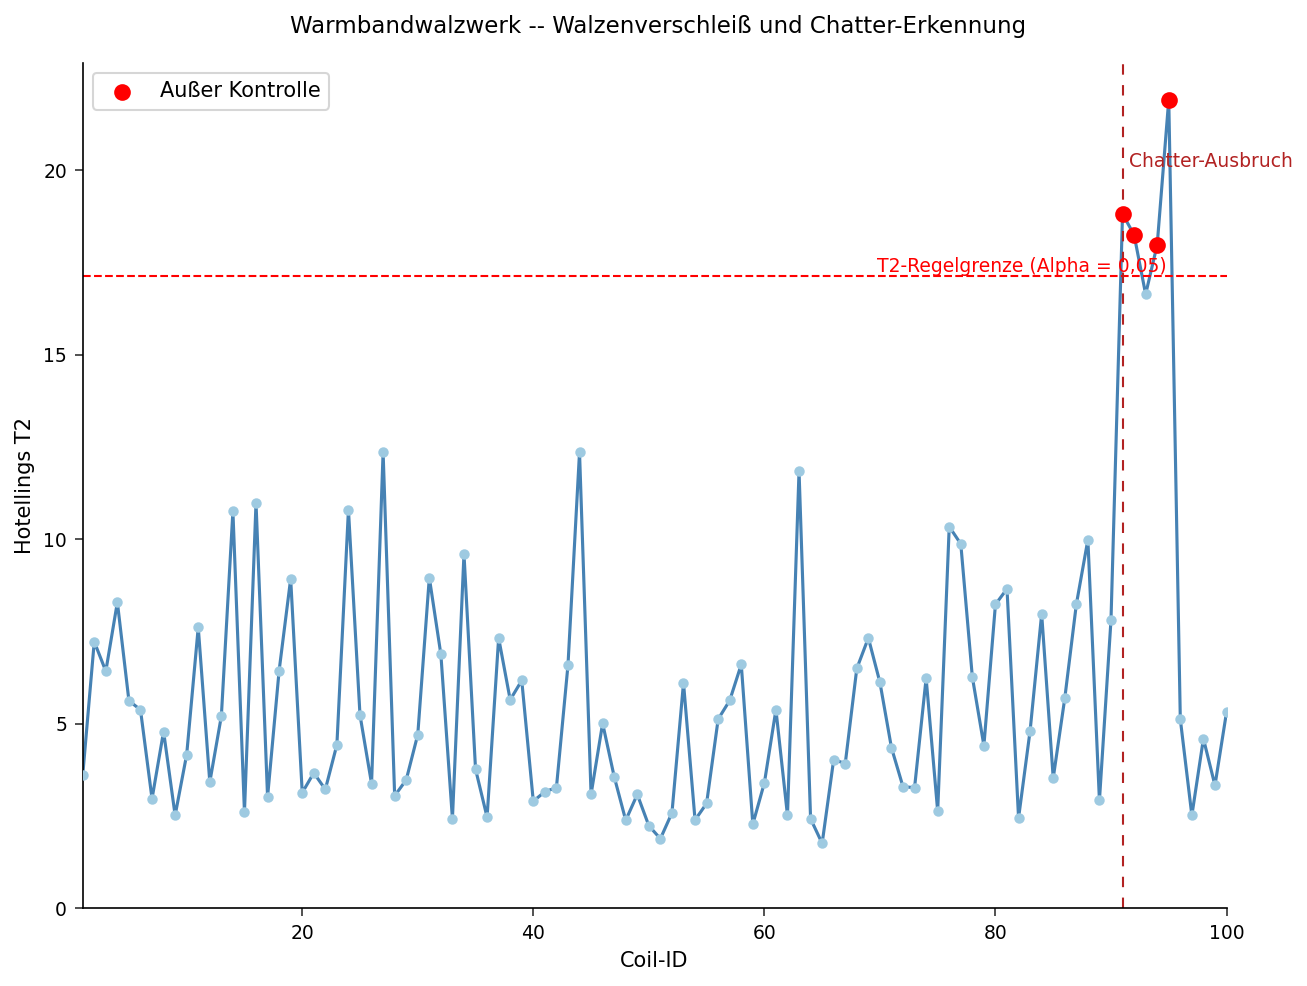

In [4]:
PROZEDUR SGPLOT DATEN=mill_scores;
  SERIES  x=coil_id y=_TSQUARED /
          LINEATTRS=(color=steelblue thickness=1.5);
  SCATTER x=coil_id y=_TSQUARED /
          MARKERATTRS=(SYMBOL=circlefilled size=4 color=cx9ecae1);
  SCATTER x=coil_id y=t2_alarm /
          MARKERATTRS=(SYMBOL=circlefilled size=7 color=red)
          legendlabel='Außer Kontrolle';
  REFLINE _LIMIT / AXIS=y
          BEZEICHNUNG='T2-Regelgrenze (Alpha = 0,05)'
          LINEATTRS=(color=red pattern=dash);
  REFLINE 91 / AXIS=x BEZEICHNUNG='Chatter-Ausbruch'
          LINEATTRS=(color=firebrick pattern=shortdash);
  XAXIS BEZEICHNUNG='Coil-ID' MIN=1 MAX=100;
  YAXIS BEZEICHNUNG='Hotellings T2' MIN=0;
  TITEL 'Warmbandwalzwerk -- Walzenverschleiß und Chatter-Erkennung';
AUSFÜHREN;


---

### Schritt 4 — Die außer Kontrolle geratenen Coils quantifizieren

Die außer Kontrolle geratenen Coils werden in einen separaten Datensatz
für die Qualitätsstelle geleitet. `PROC MEANS` stellt das *T*&sup2;-Niveau
der markierten Coils der Population im Regelzustand gegenüber, und die
markierten Coils werden für die nachgelagerte Ausschuss-/Nacharbeits-
Weiterleitung exportiert.


In [5]:
DATEN mill_ooc;
  FESTLEGEN mill_scores;
  WENN _SIGNAL = 1;
AUSFÜHREN;

PROC MEANS DATEN=mill_scores n mean MAX maxdec=2;
  KLASSE _SIGNAL;
  VAR _TSQUARED;
  BEZEICHNUNG _SIGNAL='Regelzustand' _TSQUARED='T2-Wert';
  TITEL 'T2 nach Regelzustand (0 = in Kontrolle, 1 = Signal)';
AUSFÜHREN;

PROC PRINT DATEN=mill_ooc noobs;
  VAR coil_id _TSQUARED _LIMIT;
  BEZEICHNUNG coil_id='Coil-ID' _TSQUARED='T2-Wert' _LIMIT='Regelgrenze';
  TITEL 'Außer Kontrolle geratene Coils, markiert zur Prüfung';
AUSFÜHREN;

PROZEDUR EXPORT DATEN=mill_ooc
            OUTFILE='steel_mill_ooc_coils.csv'
            DBMS=csv REPLACE;
AUSFÜHREN;


                                  T2 nach Regelzustand (0 = in Kontrolle, 1 = Signal)                                   

                                                  The MEANS Procedure

                                         Analysis Variable : _TSQUARED T2-Wert

        Regelzustand          N Obs           Mean        Maximum
        ---------------------------------------------------------
        0                        96           5.39          16.64
        1                         4          19.24          21.91
        ---------------------------------------------------------

                                  Außer Kontrolle geratene Coils, markiert zur Prüfung                                  

Coil-ID    T2-Wert  Regelgrenze
     91  18.813814    17.133408
     92  18.249361    17.133408
     94  17.981792    17.133408
     95  21.912329    17.133408




NOTE: DATA mill_ooc


NOTE: Read 100 rows from mill_scores.
NOTE: Wrote mill_ooc (4 rows, 25 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC PRINT data=mill_ooc

NOTE: PROC PRINT completed: 4 observations printed, 3 variables
NOTE: PROC EXPORT data=mill_ooc outfile=steel_mill_ooc_coils.csv

NOTE: Exported 4 rows to steel_mill_ooc_coils.csv.


## Ergebnisse

- **Überwachte Coils**: 100; **Regelgrenze** *T*&sup2; = **17,13**
  (&alpha; = 0,05).
- **Außer Kontrolle geratene Coils**: **4** — Coils **91, 92, 94, 95**,
  alle innerhalb des eingebrachten Chatter-Fensters (91–95). Coil 93
  erreicht einen Spitzenwert von *T*&sup2; = 16,64, knapp unter der
  Grenze.
- **Spitzenschwere**: *T*&sup2; = **21,91** bei Coil 95 (etwa das
  1,3-Fache der Grenze); die Coils im Regelzustand liegen im Mittel bei
  *T*&sup2; ≈ **5,4**.
- **Verschleiß vs. Fehler**: Die allmähliche Rampe des Walzenverschleißes
  hebt die Baseline der späteren Coils an, überschreitet die Grenze aber
  nie von selbst, sodass die einzelne multivariate Regelkarte langsame
  Drift (beobachten) vom akuten Chatter-Ereignis (handeln) unterscheidet.
- **Maßnahme**: Die vier markierten Coils werden zur Prüfung und
  Ausschuss-/Nacharbeits-Weiterleitung nach `steel_mill_ooc_coils.csv`
  exportiert; die Chatter-Signatur weist auf das Stützwalzenlager hin,
  das vor der nächsten Kampagne zu prüfen ist.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Vertraulich
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Bereitgestellt von <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>